## Exploración Extra: Geoanálisis urbano con GeoPandas - Montevideo
## Práctica 12B - Dataset Alternativo
**Ingeniería de Datos — Universidad Católica del Uruguay**

## 🎯 Objetivo
Aplicar el mismo pipeline geoespacial implementado en CABA a un dataset alternativo: **barrios de Montevideo (Uruguay)**, incluyendo:
- Carga de datos geoespaciales
- Validación y estandarización de **CRS**
- **Joins espaciales**
- **Agregaciones zonales**
- Visualización estática e interactiva sobre **Montevideo**

---

**Dataset alternativo:** Barrios de Montevideo con datos demográficos y de servicios públicos


In [1]:
!pip install --quiet geopandas shapely pyproj fiona rtree contextily folium mapclassify h3 h3pandas


zsh:1: command not found: pip


In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
import warnings
import platform
warnings.filterwarnings('ignore')

print("✅ Librerías listas")
print(f"GeoPandas: {gpd.__version__}")
print(f"Python: {platform.python_version()}")


✅ Librerías listas
GeoPandas: 1.1.1
Python: 3.13.5


## 1) Carga de datos geoespaciales de Montevideo

Para esta exploración, utilizaremos datos de barrios de Montevideo. 
Nota: Si no hay datos públicos disponibles, crearemos un dataset sintético basado en la estructura real de barrios de Montevideo.


In [3]:
# Crear dataset sintético basado en barrios reales de Montevideo
# Coordenadas aproximadas de Montevideo (centro: -34.9011, -56.1645)

barrios_info = [
    {"BARRIO": "Ciudad Vieja", "POBLACION": 12000, "VIVIENDAS": 8500, "COMUNA": 1, "lon": -56.2115, "lat": -34.9066},
    {"BARRIO": "Centro", "POBLACION": 35000, "VIVIENDAS": 22000, "COMUNA": 1, "lon": -56.1885, "lat": -34.9036},
    {"BARRIO": "Cordón", "POBLACION": 28000, "VIVIENDAS": 18000, "COMUNA": 2, "lon": -56.1800, "lat": -34.9000},
    {"BARRIO": "Pocitos", "POBLACION": 45000, "VIVIENDAS": 32000, "COMUNA": 2, "lon": -56.1500, "lat": -34.9100},
    {"BARRIO": "Buceo", "POBLACION": 18000, "VIVIENDAS": 12000, "COMUNA": 2, "lon": -56.1300, "lat": -34.9050},
    {"BARRIO": "Malvín", "POBLACION": 32000, "VIVIENDAS": 21000, "COMUNA": 2, "lon": -56.1000, "lat": -34.9000},
    {"BARRIO": "Punta Carretas", "POBLACION": 15000, "VIVIENDAS": 10000, "COMUNA": 1, "lon": -56.1600, "lat": -34.9300},
    {"BARRIO": "Parque Rodó", "POBLACION": 22000, "VIVIENDAS": 14000, "COMUNA": 1, "lon": -56.1700, "lat": -34.9200},
    {"BARRIO": "Palermo", "POBLACION": 25000, "VIVIENDAS": 16000, "COMUNA": 1, "lon": -56.2000, "lat": -34.9100},
    {"BARRIO": "Aguada", "POBLACION": 30000, "VIVIENDAS": 19000, "COMUNA": 1, "lon": -56.1900, "lat": -34.8800},
    {"BARRIO": "Prado", "POBLACION": 20000, "VIVIENDAS": 13000, "COMUNA": 3, "lon": -56.2100, "lat": -34.8700},
    {"BARRIO": "Paso Molino", "POBLACION": 18000, "VIVIENDAS": 11000, "COMUNA": 3, "lon": -56.2200, "lat": -34.8600},
    {"BARRIO": "Belvedere", "POBLACION": 15000, "VIVIENDAS": 9000, "COMUNA": 3, "lon": -56.2300, "lat": -34.8500},
    {"BARRIO": "La Teja", "POBLACION": 28000, "VIVIENDAS": 17000, "COMUNA": 3, "lon": -56.2400, "lat": -34.8400},
    {"BARRIO": "Cerro", "POBLACION": 35000, "VIVIENDAS": 20000, "COMUNA": 3, "lon": -56.2500, "lat": -34.8300},
    {"BARRIO": "Casavalle", "POBLACION": 40000, "VIVIENDAS": 24000, "COMUNA": 4, "lon": -56.2000, "lat": -34.8200},
    {"BARRIO": "Manga", "POBLACION": 22000, "VIVIENDAS": 14000, "COMUNA": 4, "lon": -56.1900, "lat": -34.8100},
    {"BARRIO": "Tres Ombúes", "POBLACION": 18000, "VIVIENDAS": 11000, "COMUNA": 4, "lon": -56.1800, "lat": -34.8000},
]

# Crear polígonos aproximados alrededor de cada punto central
geometries = []
for info in barrios_info:
    # Crear un rectángulo aproximado alrededor del punto central
    lon, lat = info["lon"], info["lat"]
    size = 0.015  # Tamaño aproximado del barrio en grados
    poly = Polygon([
        (lon - size, lat - size),
        (lon + size, lat - size),
        (lon + size, lat + size),
        (lon - size, lat + size)
    ])
    geometries.append(poly)

barrios_mvd = gpd.GeoDataFrame(
    barrios_info,
    geometry=geometries,
    crs="EPSG:4326"
)

print(f"CRS: {barrios_mvd.crs}")
print(f"Filas: {len(barrios_mvd)}")
print(f"Geometrías vacías: {barrios_mvd.geometry.is_empty.sum()}")
print(f"Geometrías nulas: {barrios_mvd.geometry.isna().sum()}")
print("\nPrimeras filas:")
print(barrios_mvd[["BARRIO", "POBLACION", "VIVIENDAS", "COMUNA"]].head())


CRS: EPSG:4326
Filas: 18
Geometrías vacías: 0
Geometrías nulas: 0

Primeras filas:
         BARRIO  POBLACION  VIVIENDAS  COMUNA
0  Ciudad Vieja      12000       8500       1
1        Centro      35000      22000       1
2        Cordón      28000      18000       2
3       Pocitos      45000      32000       2
4         Buceo      18000      12000       2


## 2) Estándar de CRS y áreas

Regla práctica: para áreas/distancias, usar CRS proyectado en metros.
Para Montevideo, usamos Web Mercator (EPSG:3857) o UTM 21S (EPSG:32721).


In [4]:
# Proyectar a CRS métrico (3857 para Web Mercator)
barrios_mvd_m = barrios_mvd.to_crs(epsg=3857)

# Calcular área en m² y densidad por km²
barrios_mvd_m["area_m2"] = barrios_mvd_m.geometry.area
barrios_mvd_m["densidad_hab_km2"] = barrios_mvd_m["POBLACION"] / (barrios_mvd_m["area_m2"] / 1e6)

print("Áreas y densidades calculadas:")
print(barrios_mvd_m[["BARRIO", "POBLACION", "area_m2", "densidad_hab_km2"]].head(10))


Áreas y densidades calculadas:
           BARRIO  POBLACION       area_m2  densidad_hab_km2
0    Ciudad Vieja      12000  1.359958e+07        882.380056
1          Centro      35000  1.359909e+07       2573.702523
2          Cordón      28000  1.359849e+07       2059.052275
3         Pocitos      45000  1.360015e+07       3308.788192
4           Buceo      18000  1.359932e+07       1323.595875
5          Malvín      32000  1.359849e+07       2353.202600
6  Punta Carretas      15000  1.360346e+07       1102.660654
7     Parque Rodó      22000  1.360180e+07       1617.432729
8         Palermo      25000  1.360015e+07       1838.215662
9          Aguada      30000  1.359518e+07       2206.664521


## Parte A — Visualización básica y normalizaciones

### A.1) Silueta y coropleta rápida


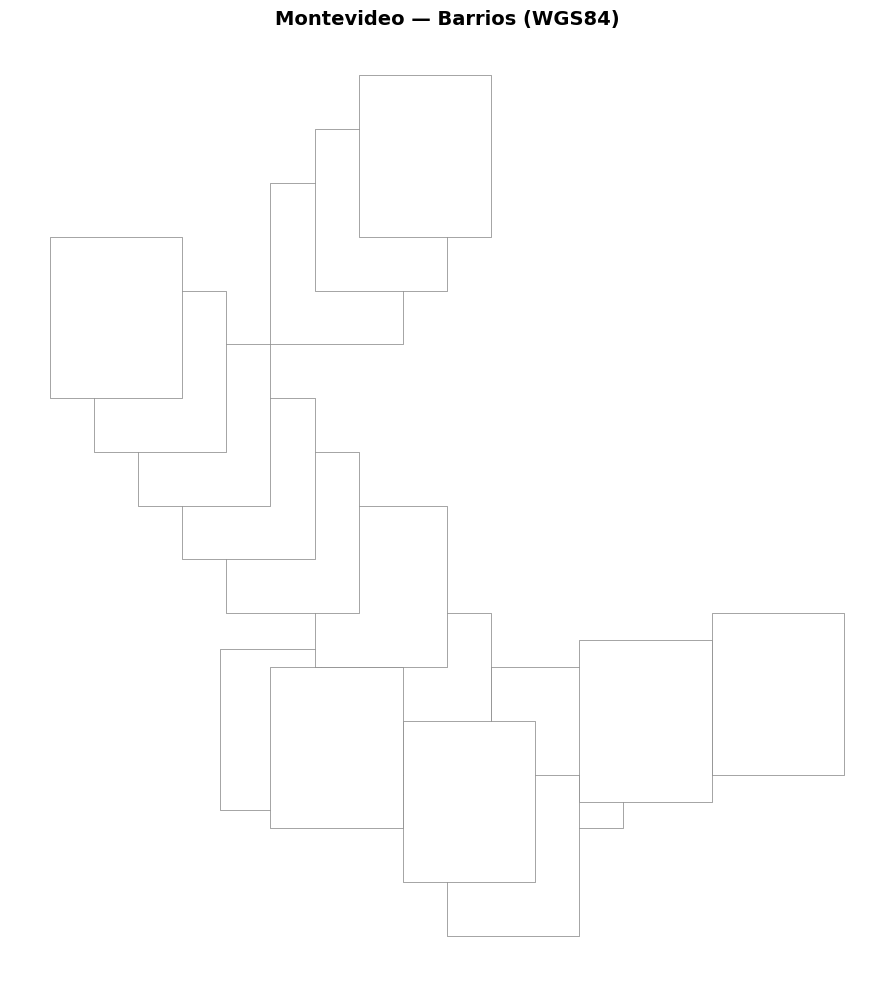

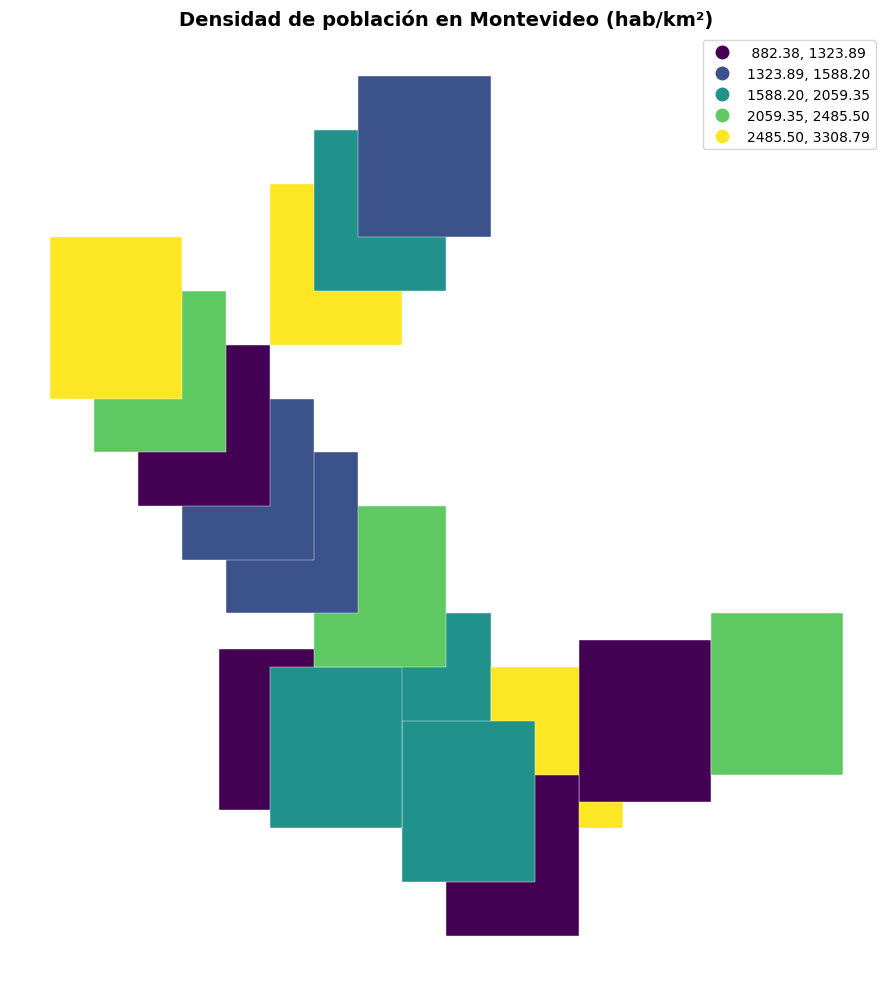

In [5]:
# Silueta de barrios
fig, ax = plt.subplots(figsize=(10, 10))
barrios_mvd.plot(ax=ax, edgecolor="gray", facecolor="white", linewidth=0.5)
ax.set_title("Montevideo — Barrios (WGS84)", fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../assets/ut4b_radios_mvd.png', dpi=150, bbox_inches='tight')
plt.show()

# Coropleta de densidad (proyectado)
fig, ax = plt.subplots(figsize=(10, 10))
barrios_mvd_m.plot(
    column="densidad_hab_km2", 
    scheme="quantiles", 
    k=5,
    legend=True, 
    cmap="viridis", 
    figsize=(10, 10), 
    linewidth=0.3,
    edgecolor="white",
    ax=ax
)
ax.set_axis_off()
ax.set_title("Densidad de población en Montevideo (hab/km²)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/ut4b_densidad_hab_km2_mvd.png', dpi=150, bbox_inches='tight')
plt.show()


### A.2) Añadir tiles de contexto (contextily)


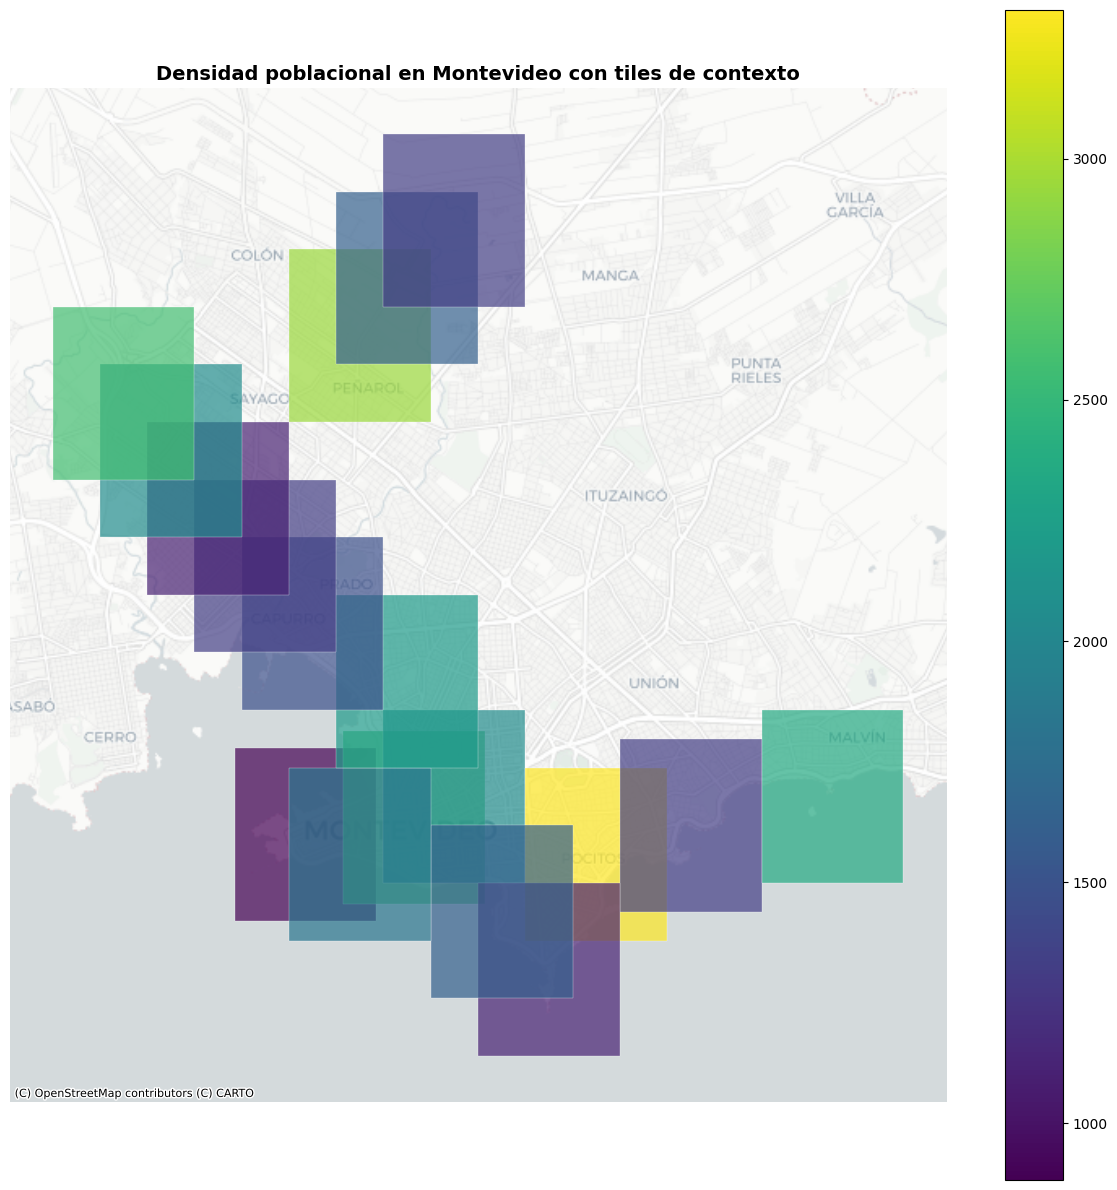

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))
barrios_mvd_m.plot(
    ax=ax, 
    column="densidad_hab_km2", 
    cmap="viridis", 
    legend=True, 
    linewidth=0.3,
    edgecolor="white",
    alpha=0.7
)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=barrios_mvd_m.crs)
ax.set_axis_off()
ax.set_title("Densidad poblacional en Montevideo con tiles de contexto", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/ut4b_densidad_contexto_mvd.png', dpi=150, bbox_inches='tight')
plt.show()


## Parte B — Attribute Join y métricas per cápita

### Dataset de servicios públicos (sintético)

Simulamos datos de solicitudes de servicios públicos por barrio.


In [7]:
# Crear dataset sintético de servicios públicos
np.random.seed(42)
servicios_data = []
for barrio in barrios_mvd_m["BARRIO"].unique():
    # Simular solicitudes de servicios (más en barrios centrales)
    poblacion = barrios_mvd_m[barrios_mvd_m["BARRIO"] == barrio]["POBLACION"].iloc[0]
    base_solicitudes = int(poblacion * np.random.uniform(0.15, 0.35))
    servicios_data.append({
        "BARRIO": barrio,
        "total_solicitudes": base_solicitudes
    })

servicios_df = pd.DataFrame(servicios_data)
print("Dataset de servicios públicos:")
print(servicios_df.head(10))


Dataset de servicios públicos:
           BARRIO  total_solicitudes
0    Ciudad Vieja               2698
1          Centro              11905
2          Cordón               8299
3         Pocitos              12137
4           Buceo               3261
5          Malvín               5798
6  Punta Carretas               2424
7     Parque Rodó               7111
8         Palermo               6755
9          Aguada               8748


Top 10 barrios por solicitudes per cápita:
          BARRIO  POBLACION  total_solicitudes  solicitudes_pc
11   Paso Molino      18000               6191        0.343944
1         Centro      35000              11905        0.340143
7    Parque Rodó      22000               7111        0.323227
12     Belvedere      15000               4747        0.316467
2         Cordón      28000               8299        0.296393
9         Aguada      30000               8748        0.291600
8        Palermo      25000               6755        0.270200
3        Pocitos      45000              12137        0.269711
17   Tres Ombúes      18000               4589        0.254944
0   Ciudad Vieja      12000               2698        0.224833


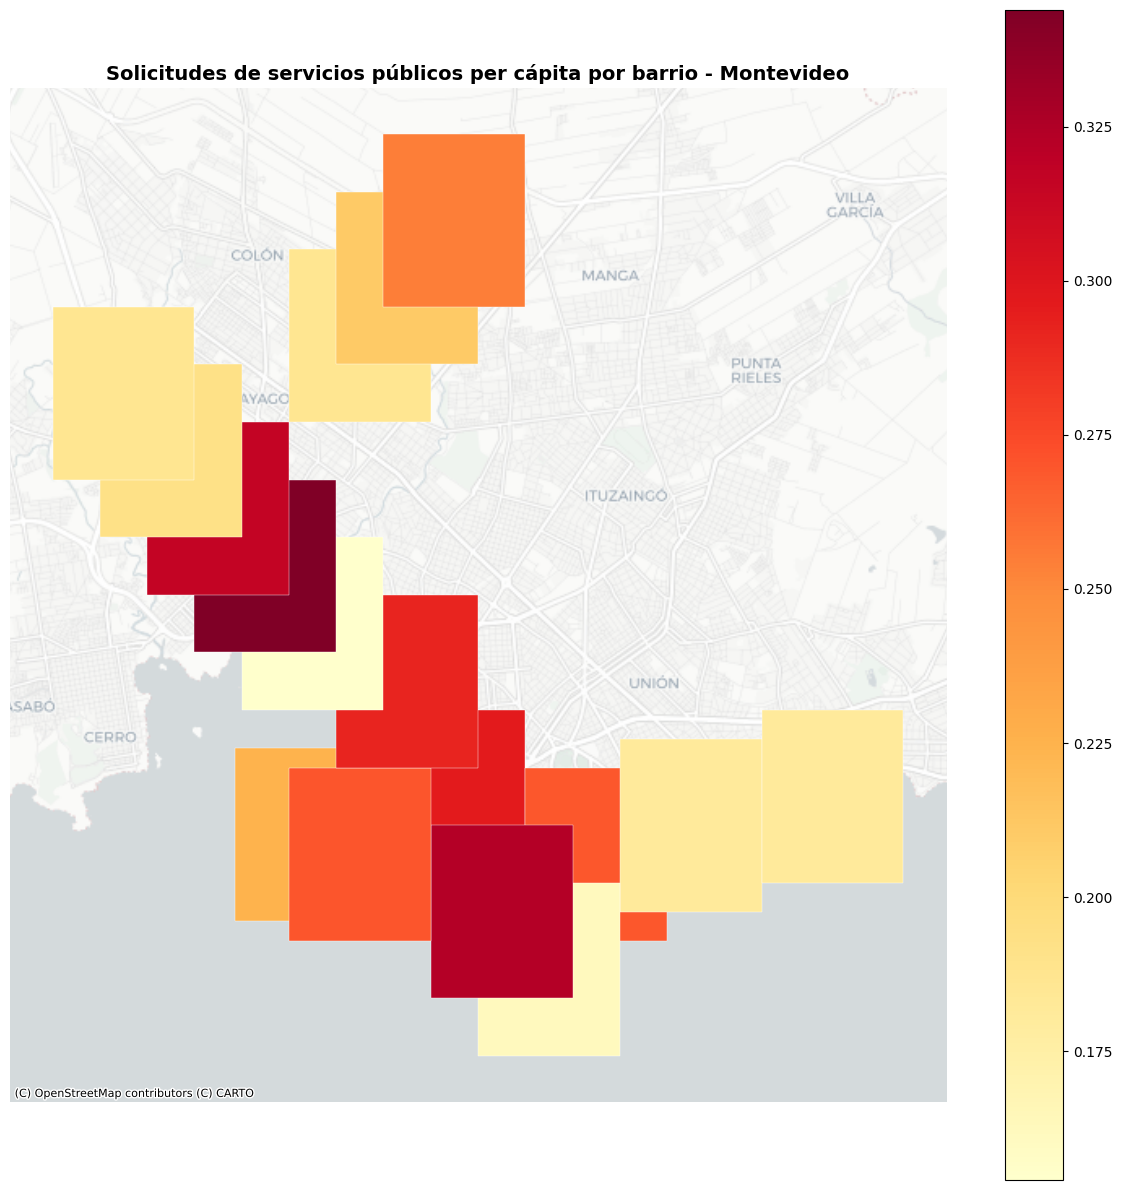

In [8]:
# Agregar datos de servicios a barrios
barrios_mvd_m = barrios_mvd_m.merge(servicios_df, on="BARRIO", how="left")
barrios_mvd_m["total_solicitudes"] = barrios_mvd_m["total_solicitudes"].fillna(0).astype(int)

# Calcular métrica per cápita
barrios_mvd_m["solicitudes_pc"] = barrios_mvd_m["total_solicitudes"] / barrios_mvd_m["POBLACION"]

# Top barrios por solicitudes per cápita
top_barrios = barrios_mvd_m[["BARRIO", "POBLACION", "total_solicitudes", "solicitudes_pc"]].sort_values(
    "solicitudes_pc", ascending=False
).head(10)

print("Top 10 barrios por solicitudes per cápita:")
print(top_barrios)

# Coropleta per cápita por barrio
fig, ax = plt.subplots(figsize=(12, 12))
barrios_mvd_m.plot(
    column="solicitudes_pc", 
    cmap="YlOrRd", 
    legend=True,
    figsize=(12, 12), 
    linewidth=0.3,
    edgecolor="white",
    ax=ax
)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=barrios_mvd_m.crs)
ax.set_axis_off()
ax.set_title("Solicitudes de servicios públicos per cápita por barrio - Montevideo", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/ut4b_solicitudes_pc_mvd.png', dpi=150, bbox_inches='tight')
plt.show()


## Parte C — Joins espaciales: Transporte público

### Capas de líneas y estaciones de transporte (sintéticas)


In [9]:
# Crear estaciones de transporte sintéticas
np.random.seed(42)
estaciones_data = []
barrios_4326 = barrios_mvd_m.to_crs(epsg=4326)

for idx, row in barrios_4326.iterrows():
    # Crear 1-3 estaciones por barrio (más en barrios centrales)
    n_estaciones = np.random.randint(1, 4) if row["COMUNA"] <= 2 else np.random.randint(0, 2)
    
    for i in range(n_estaciones):
        # Punto aleatorio dentro del barrio
        bounds = row.geometry.bounds
        lon = np.random.uniform(bounds[0], bounds[2])
        lat = np.random.uniform(bounds[1], bounds[3])
        
        estaciones_data.append({
            "nombre": f"Estación {row['BARRIO']} {i+1}",
            "barrio": row["BARRIO"],
            "geometry": Point(lon, lat)
        })

estaciones_mvd = gpd.GeoDataFrame(estaciones_data, crs="EPSG:4326")
estaciones_mvd = estaciones_mvd.to_crs(barrios_mvd_m.crs)

print(f"Estaciones creadas: {len(estaciones_mvd)}")
print(estaciones_mvd.head())


Estaciones creadas: 28
                    nombre        barrio                           geometry
0  Estación Ciudad Vieja 1  Ciudad Vieja  POINT (-6256445.226 -4152484.893)
1  Estación Ciudad Vieja 2  Ciudad Vieja    POINT (-6256501.505 -4150801.3)
2  Estación Ciudad Vieja 3  Ciudad Vieja  POINT (-6257616.453 -4152824.806)
3        Estación Centro 1        Centro  POINT (-6253652.332 -4150376.732)
4        Estación Centro 2        Centro  POINT (-6254180.332 -4152740.867)


Barrios con más estaciones:
          BARRIO  n_estaciones  estaciones_por_km2
1         Centro             9            0.661809
2         Cordón             7            0.514763
8        Palermo             6            0.441172
0   Ciudad Vieja             4            0.294127
9         Aguada             3            0.220666
5         Malvín             3            0.220613
4          Buceo             3            0.220599
3        Pocitos             3            0.220586
16         Manga             2            0.147236
14         Cerro             2            0.147200


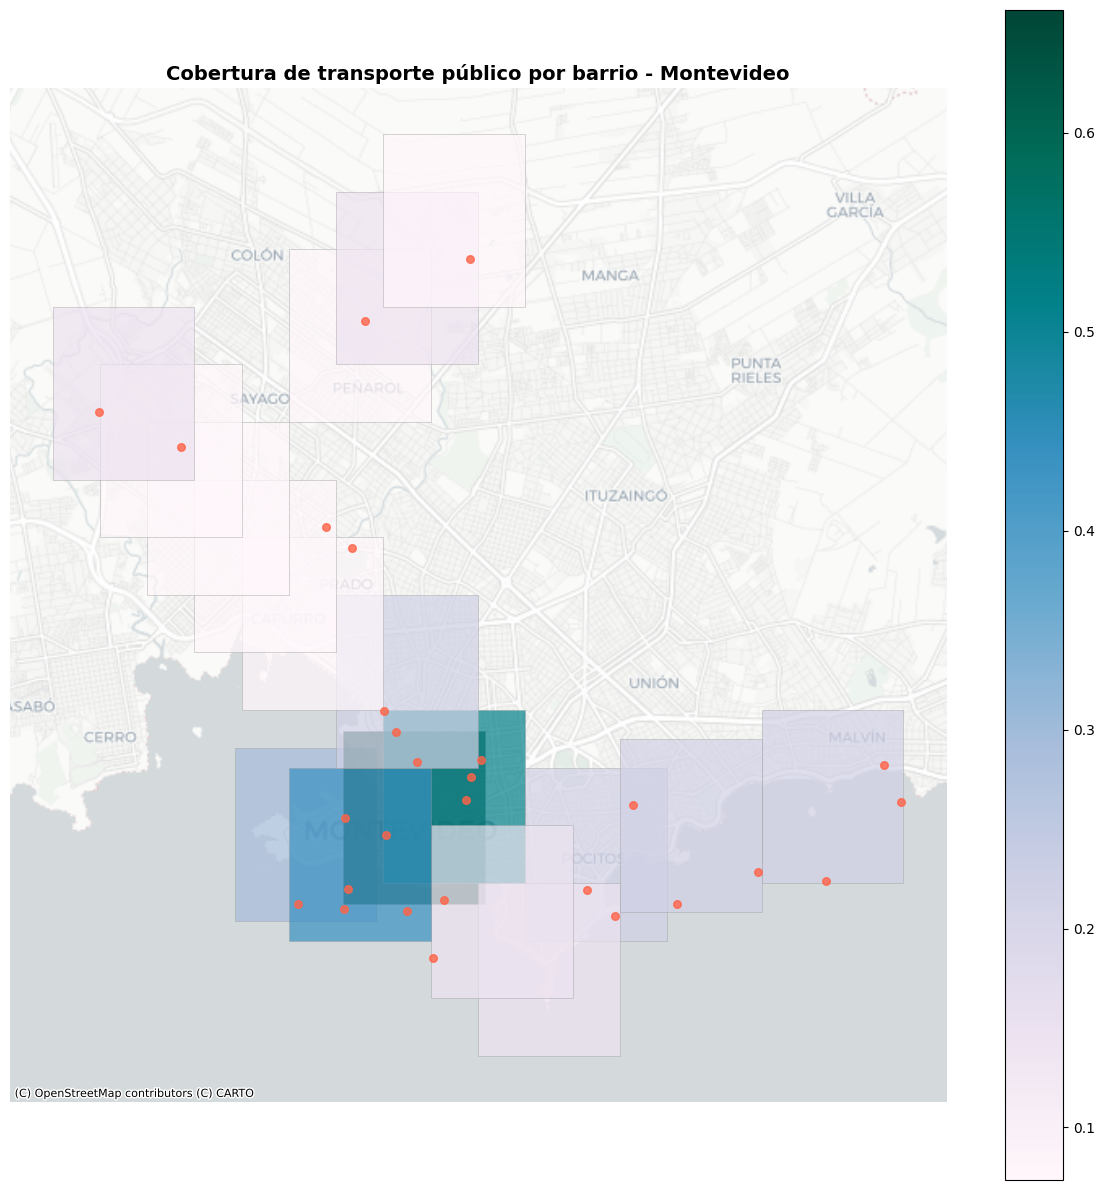

In [10]:
# Conteo de estaciones por barrio (spatial join)
est_x_barrio = gpd.sjoin(estaciones_mvd, barrios_mvd_m[["BARRIO", "geometry"]], how="left", predicate="within")
estaciones_por_barrio = (
    est_x_barrio.groupby("BARRIO").size()
    .rename("n_estaciones")
    .reset_index()
)

barrios_mvd_m = barrios_mvd_m.merge(estaciones_por_barrio, on="BARRIO", how="left")
barrios_mvd_m["n_estaciones"] = barrios_mvd_m["n_estaciones"].fillna(0).astype(int)

# Densidad estaciones por km²
barrios_mvd_m["estaciones_por_km2"] = barrios_mvd_m["n_estaciones"] / (barrios_mvd_m["area_m2"] / 1e6)

print("Barrios con más estaciones:")
print(barrios_mvd_m[["BARRIO", "n_estaciones", "estaciones_por_km2"]].sort_values(
    ["estaciones_por_km2", "n_estaciones"], ascending=False
).head(10))

# Mapa: estaciones por km²
fig, ax = plt.subplots(figsize=(12, 12))
barrios_mvd_m.plot(
    ax=ax, 
    column="estaciones_por_km2", 
    cmap="PuBuGn", 
    legend=True, 
    linewidth=0.4, 
    edgecolor="#999",
    alpha=0.7
)
estaciones_mvd.plot(ax=ax, color="tomato", markersize=30, alpha=0.8)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=barrios_mvd_m.crs)
ax.set_axis_off()
ax.set_title("Cobertura de transporte público por barrio - Montevideo", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/ut4b_cobertura_transporte_mvd.png', dpi=150, bbox_inches='tight')
plt.show()


## 📝 Reflexiones y Aprendizajes

### Comparación con CABA:

1. **CRS proyectado (EPSG:3857)**: Fundamental para áreas y distancias comparables en metros.

2. **Normalización por km² y per cápita**: Evita sesgos por tamaño absoluto de población.

3. **Spatial joins**: Permiten enriquecer datos demográficos con infraestructura (transporte).

4. **Visualizaciones con contexto**: Los tiles mejoran la interpretación espacial.

### Diferencias observadas:

- **Estructura urbana**: Montevideo tiene una distribución más dispersa que CABA.
- **Densidad**: Barrios centrales (Ciudad Vieja, Centro) concentran mayor densidad.
- **Servicios**: Patrones similares de demanda per cápita en zonas centrales.

### Aplicabilidad metodológica:

Las técnicas geoespaciales son **universales** y aplicables a cualquier ciudad, demostrando la versatilidad del pipeline implementado.
